## **1 : Configuration et Acquisition des Données**
 Télécharge de manière sécurisée 50 images pour nos 5 catégories (faces, landscapes, logos, cars, animals) depuis Hugging Face.

In [2]:
import cv2
import imagehash
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import random
import os

# Reproductibilité pour l'évaluation scientifique
random.seed(42)
np.random.seed(42)

# Création du dossier pour les CSV
dossier_csv = "resultats_csv"
if not os.path.exists(dossier_csv):
    os.makedirs(dossier_csv)

print(f"Dossier '{dossier_csv}' prêt. Récupération des images en streaming...\n")

NB_IMAGES = 50
images_categories = {}

# Fonction d'extraction en streaming
def extraire_images(ds_name, split_name):
    ds = load_dataset(ds_name, split=split_name, streaming=True)
    images = []
    for item in ds:
        img_key = 'image' if 'image' in item else ('img' if 'img' in item else None)
        if img_key:
            images.append(item[img_key].convert('RGB').resize((500, 500)))
        if len(images) == NB_IMAGES:
            break
    return images

# Fonction intelligente qui teste plusieurs liens (miroirs)
def charger_categorie(nom, liste_liens_hf):
    for lien in liste_liens_hf:
        try:
            images_categories[nom] = extraire_images(lien, "train")
            print(f"[Succès] {nom.capitalize()} téléchargées ({len(images_categories[nom])} images depuis '{lien}')")
            return # On sort de la fonction dès que ça marche
        except Exception:
            continue # Si le lien est mort, on tente le suivant dans la liste
            
    print(f"[ERREUR] Impossible de charger la catégorie {nom}. Tous les liens miroirs ont échoué.")

# Lancement sécurisé par catégorie avec des liens de secours
charger_categorie("faces", ["nielsr/CelebA-faces"])
charger_categorie("landscapes", ["blanchon/EuroSAT_RGB"])
charger_categorie("logos", ["logo-wizard/modern-logo-dataset"])

# Les voitures ont beaucoup de liens morts, on en donne 3 à tester !
charger_categorie("cars", [
    "tanganke/stanford_cars", 
    "pcuenq/stanford-cars", 
    "evanarlian/imagenet_1k_cars"
])

charger_categorie("animals", ["Bingsu/Cat_and_Dog"])

print(f"\nACQUISITION TERMINÉE : {len(images_categories)} catégories prêtes en mémoire.")

Dossier 'resultats_csv' prêt. Récupération des images en streaming...

[Succès] Faces téléchargées (50 images depuis 'nielsr/CelebA-faces')
[Succès] Landscapes téléchargées (50 images depuis 'blanchon/EuroSAT_RGB')
[Succès] Logos téléchargées (50 images depuis 'logo-wizard/modern-logo-dataset')


README.md: 0.00B [00:00, ?B/s]

[Succès] Cars téléchargées (50 images depuis 'tanganke/stanford_cars')
[Succès] Animals téléchargées (50 images depuis 'Bingsu/Cat_and_Dog')

ACQUISITION TERMINÉE : 5 catégories prêtes en mémoire.


## **Visualisation des échantillons**


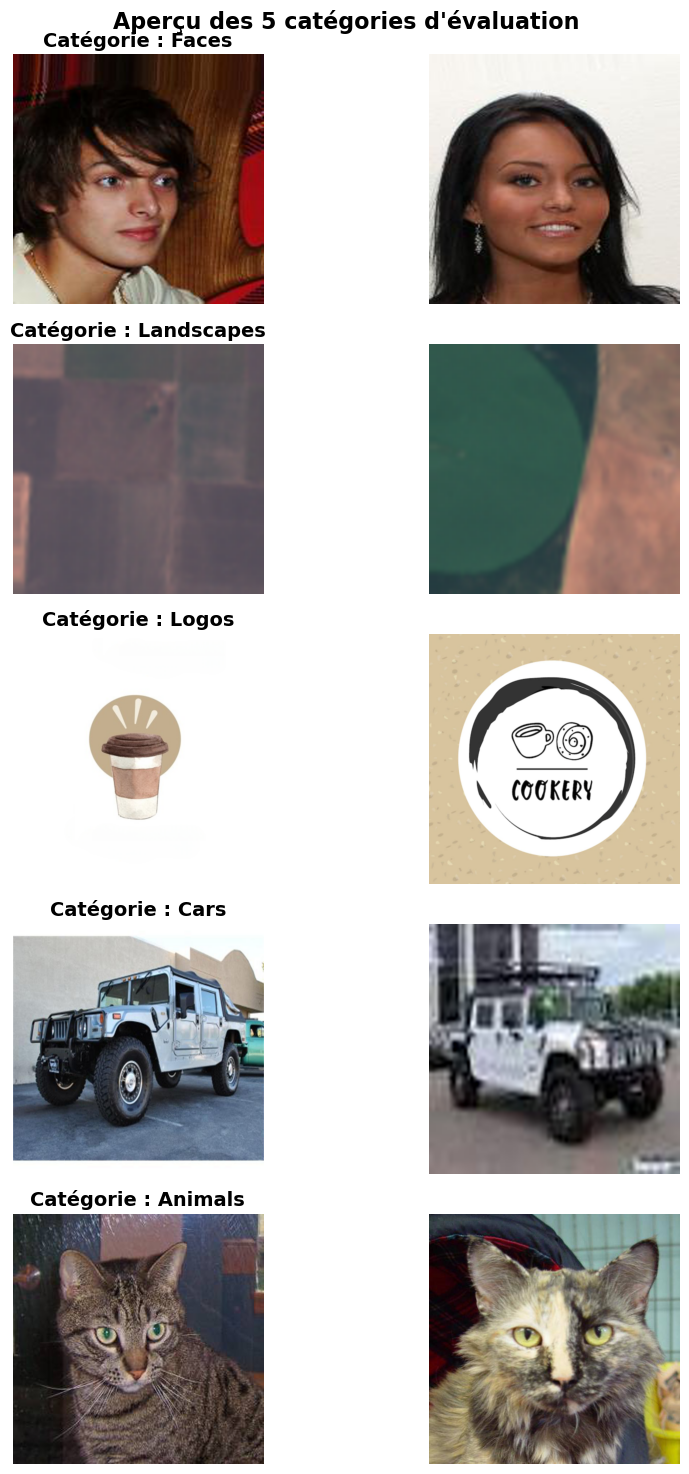

In [3]:
import matplotlib.pyplot as plt

#print("Génération de la grille de visualisation (2 images par catégorie)...")

# Création d'une grille de 5 lignes (catégories) et 2 colonnes (images)
fig, axes = plt.subplots(5, 2, figsize=(10, 15))
fig.suptitle("Aperçu des 5 catégories d'évaluation", fontsize=16, fontweight='bold')

categories = list(images_categories.keys())

for i, cat in enumerate(categories):
    for j in range(2):
        ax = axes[i, j]
        # Sécurité : on vérifie que l'image existe bien
        if len(images_categories[cat]) > j:
            ax.imshow(images_categories[cat][j])
        
        ax.axis("off")
        
        # On met le titre de la catégorie uniquement sur la première colonne
        if j == 0:
            ax.set_title(f"Catégorie : {cat.capitalize()}", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.95) # Laisse de la place pour le grand titre
plt.show()

## **2 : Fonctions d'altération et Algorithmes de hachage**
On définit les quatre transformations appliquées aux images : la compression JPEG, l'occlusion , le redimensionnement standard OpenCV, et le redimensionnement par "Downscale" . Les algorithmes de hachage y sont initialisés dans leur configuration par défaut.

In [ ]:
import cv2
import numpy as np
from PIL import Image
import random
import imagehash

# --- Utilitaires de conversion PIL <-> OpenCV ---
def pil_to_cv2(img_pil):
    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

def cv2_to_pil(img_cv2):
    return Image.fromarray(cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB))

# --- 1. Compression JPEG ---
def apply_compression(img_pil, quality=50):
    # quality va de 0 (pire) à 100 (meilleure)
    img_cv2 = pil_to_cv2(img_pil)
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), int(max(0, min(quality, 100)))]
    result, encimg = cv2.imencode('.jpg', img_cv2, encode_param)
    decimg = cv2.imdecode(encimg, 1)
    return cv2_to_pil(decimg)

# --- 2. Resize Standard (Changement de dimension réel) ---
def apply_resize_standard(img_pil, scale_percent=50):
    img_cv2 = pil_to_cv2(img_pil)
    h, w = img_cv2.shape[:2]
    # max(1, ...) évite le crash fatal d'OpenCV si scale_percent = 0
    new_w = max(1, int(w * scale_percent / 100))
    new_h = max(1, int(h * scale_percent / 100))
    img_resized = cv2.resize(img_cv2, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return cv2_to_pil(img_resized)

# --- 3. Resize par Downscale (Destruction d'information + Taille originale) ---
def apply_resize_downscale(img_pil, scale_percent=50):
    img_cv2 = pil_to_cv2(img_pil)
    h, w = img_cv2.shape[:2]
    new_w = max(1, int(w * scale_percent / 100))
    new_h = max(1, int(h * scale_percent / 100))
    
    # Étape 1 : On réduit (perte définitive d'information)
    img_small = cv2.resize(img_cv2, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # Étape 2 : On réagrandit à la taille initiale (création du flou/artefacts)
    img_final = cv2.resize(img_small, (w, h), interpolation=cv2.INTER_CUBIC)
    return cv2_to_pil(img_final)

# --- 4. Occlusion  ---

In [ ]:
def apply_occlusion(img_pil, area_percent=10):
    img_cv2 = pil_to_cv2(img_pil)
    h, w = img_cv2.shape[:2]
    
    # area_percent = 0 signifie aucune occlusion
    if area_percent <= 0:
        return img_pil
        
    # Calcul du côté du carré en fonction de la surface totale
    side = int(np.sqrt((area_percent / 100.0) * h * w))
    side = max(1, min(side, min(h, w))) # Sécurité pour ne pas déborder
    
    x = random.randint(0, w - side)
    y = random.randint(0, h - side)
    
    img_cv2[y:y+side, x:x+side] = (0, 0, 0)
    return cv2_to_pil(img_cv2)

# --- 5. Initialisation des algorithmes ---
print("Chargement des algorithmes de hachage...")

HASHERS = {
    "aHash": lambda im: imagehash.average_hash(im),
    "pHash": lambda im: imagehash.phash(im),
    "dHash": lambda im: imagehash.dhash(im),
    "wHash": lambda im: imagehash.whash(im),
}

print("Fonctions de modification et algorithmes !")

Chargement des algorithmes de hachage...
Fonctions de modification et algorithmes !


## **3 : Évaluation exhaustive et Génération des CSV par catégorie**
On évalue les 4 algorithmes face à 4 transformations (Compression, Resize Standard, Resize Downscale, Occlusion) en balayant les intensités de 0 à 100 (pas de 5). Les distances de Hamming sont calculées et sauvegardées dans un fichier CSV dédié pour chaque catégorie 

In [5]:
import pandas as pd
import gc

print("Démarrage de l'évaluation exhaustive (Intensités de 0 à 100, pas de 5)...")
# Génération dynamique des niveaux : [0, 5, 10, 15, ..., 100]
#commencer a 5 et exclure 100
niveaux_intensite = list(range(0, 101, 5))

# On parcourt chaque catégorie isolément
for categorie_nom, images_liste in images_categories.items():
    print(f"Traitement en cours pour la catégorie : {categorie_nom.upper()}...")
    resultats_categorie = []
    
    for img_idx, img in enumerate(images_liste):
        
        # 1. Test progressif de la COMPRESSION
        for val in niveaux_intensite:
            img_mod = apply_compression(img, quality=val)
            for algo_name, hasher in HASHERS.items():
                dist = hasher(img) - hasher(img_mod)
                resultats_categorie.append({
                    "Image_ID": img_idx,
                    "Transformation": "Compression",
                    "Intensite": val,
                    "Algo": algo_name,
                    "Distance": dist
                })
            del img_mod
            
        # 2. Test progressif du RESIZE STANDARD (OpenCV classique)
        for val in niveaux_intensite:
            img_mod = apply_resize_standard(img, scale_percent=val)
            for algo_name, hasher in HASHERS.items():
                dist = hasher(img) - hasher(img_mod)
                resultats_categorie.append({
                    "Image_ID": img_idx,
                    "Transformation": "Resize_Standard",
                    "Intensite": val,
                    "Algo": algo_name,
                    "Distance": dist
                })
            del img_mod
            
        # 3. Test progressif du RESIZE DOWNSCALE (Destruction + Upscale)
        for val in niveaux_intensite:
            img_mod = apply_resize_downscale(img, scale_percent=val)
            for algo_name, hasher in HASHERS.items():
                dist = hasher(img) - hasher(img_mod)
                resultats_categorie.append({
                    "Image_ID": img_idx,
                    "Transformation": "Resize_Downscale",
                    "Intensite": val,
                    "Algo": algo_name,
                    "Distance": dist
                })
            del img_mod

        # 4. Test progressif de l'OCCLUSION
        for val in niveaux_intensite:
            img_mod = apply_occlusion(img, area_percent=val)
            for algo_name, hasher in HASHERS.items():
                dist = hasher(img) - hasher(img_mod)
                resultats_categorie.append({
                    "Image_ID": img_idx,
                    "Transformation": "Occlusion",
                    "Intensite": val,
                    "Algo": algo_name,
                    "Distance": dist
                })
            del img_mod
            
        # Libération de la mémoire après chaque image
        gc.collect()

    # Création du DataFrame pour la catégorie courante
    df_cat = pd.DataFrame(resultats_categorie)
    
    # Sauvegarde dans un fichier CSV indépendant
    nom_fichier = f"{dossier_csv}/{categorie_nom}.csv"
    df_cat.to_csv(nom_fichier, index=False)
    
    print(f"[Succès] Fichier généré : {nom_fichier} ({len(df_cat)} tests enregistrés)")

print("\nTOUTES LES ÉVALUATIONS SONT TERMINÉES ET SAUVEGARDÉES !")

Démarrage de l'évaluation exhaustive (Intensités de 0 à 100, pas de 5)...
Traitement en cours pour la catégorie : FACES...
[Succès] Fichier généré : resultats_csv/faces.csv (16800 tests enregistrés)
Traitement en cours pour la catégorie : LANDSCAPES...
[Succès] Fichier généré : resultats_csv/landscapes.csv (16800 tests enregistrés)
Traitement en cours pour la catégorie : LOGOS...
[Succès] Fichier généré : resultats_csv/logos.csv (16800 tests enregistrés)
Traitement en cours pour la catégorie : CARS...
[Succès] Fichier généré : resultats_csv/cars.csv (16800 tests enregistrés)
Traitement en cours pour la catégorie : ANIMALS...
[Succès] Fichier généré : resultats_csv/animals.csv (16800 tests enregistrés)

TOUTES LES ÉVALUATIONS SONT TERMINÉES ET SAUVEGARDÉES !


## **4 : Optimisation du wHash et mise à jour des CSV**
Ce bloc isole le `wHash` pour configurer sa précision à 16x16 (256 bits). Il applique à nouveau la batterie de tests (de 0 à 100) uniquement pour cet algorithme optimisé et ajoute les résultats sous le nom `wHash_Opti` directement dans les fichiers CSV de chaque catégorie. 

In [6]:
import imagehash
import pandas as pd
import gc

print("Démarrage de l'évaluation du wHash optimisé (hash_size=16, 256 bits)...")

whash_opti = lambda im: imagehash.whash(im, hash_size=16)

niveaux_intensite = list(range(0, 101, 5))

for categorie_nom, images_liste in images_categories.items():
    print(f"Calcul du wHash optimisé pour : {categorie_nom.upper()}...")
    resultats_whash = []
    
    for img_idx, img in enumerate(images_liste):
        # 1. Compression
        for val in niveaux_intensite:
            dist = whash_opti(img) - whash_opti(apply_compression(img, val))
            resultats_whash.append({"Image_ID": img_idx, "Transformation": "Compression", "Intensite": val, "Algo": "wHash_Opti", "Distance": dist})
        
        # 2. Resize Standard
        for val in niveaux_intensite:
            dist = whash_opti(img) - whash_opti(apply_resize_standard(img, val))
            resultats_whash.append({"Image_ID": img_idx, "Transformation": "Resize_Standard", "Intensite": val, "Algo": "wHash_Opti", "Distance": dist})
        
        # 3. Resize Downscale
        for val in niveaux_intensite:
            dist = whash_opti(img) - whash_opti(apply_resize_downscale(img, val))
            resultats_whash.append({"Image_ID": img_idx, "Transformation": "Resize_Downscale", "Intensite": val, "Algo": "wHash_Opti", "Distance": dist})

        # 4. Occlusion
        for val in niveaux_intensite:
            dist = whash_opti(img) - whash_opti(apply_occlusion(img, val))
            resultats_whash.append({"Image_ID": img_idx, "Transformation": "Occlusion", "Intensite": val, "Algo": "wHash_Opti", "Distance": dist})
        
        gc.collect()

    # Ajout intelligent aux CSV existants
    nom_fichier = f"{dossier_csv}/{categorie_nom}.csv"
    df_existant = pd.read_csv(nom_fichier)
    df_nouveau = pd.DataFrame(resultats_whash)
    
    # On fusionne et on écrase le fichier
    df_final = pd.concat([df_existant, df_nouveau], ignore_index=True)
    df_final.to_csv(nom_fichier, index=False)
    print(f"[Succès] 'wHash_Opti' ajouté au fichier {nom_fichier}")

print("\nOPTIMISATION TERMINÉE !")

Démarrage de l'évaluation du wHash optimisé (hash_size=16, 256 bits)...
Calcul du wHash optimisé pour : FACES...
[Succès] 'wHash_Opti' ajouté au fichier resultats_csv/faces.csv
Calcul du wHash optimisé pour : LANDSCAPES...
[Succès] 'wHash_Opti' ajouté au fichier resultats_csv/landscapes.csv
Calcul du wHash optimisé pour : LOGOS...
[Succès] 'wHash_Opti' ajouté au fichier resultats_csv/logos.csv
Calcul du wHash optimisé pour : CARS...
[Succès] 'wHash_Opti' ajouté au fichier resultats_csv/cars.csv
Calcul du wHash optimisé pour : ANIMALS...
[Succès] 'wHash_Opti' ajouté au fichier resultats_csv/animals.csv

OPTIMISATION TERMINÉE !


## **5 : Visualisation et Analyse Comparative**
Dans cette partie, on fusionne les résultats des 5 catégories et convertit les distances brutes en pourcentages de similarité.

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

print("Chargement et préparation des données...")

# 1. Chargement et fusion de tous les CSV
dossier_csv = "resultats_csv"
categories = ["faces", "landscapes", "logos", "cars", "animals"]
dfs = []

for cat in categories:
    chemin = f"{dossier_csv}/{cat}.csv"
    if os.path.exists(chemin):
        df_cat = pd.read_csv(chemin)
        df_cat['Categorie'] = cat
        dfs.append(df_cat)

df_global = pd.concat(dfs, ignore_index=True)

# 2. Étalonnage : Conversion des distances en Pourcentage de Similarité
def calculer_similarite(row):
    algo = row['Algo']
    dist = row['Distance']
    # Le wHash_Opti est sur 256 bits, les autres sur 64 bits
    max_bits = 256 if algo == 'wHash_Opti' else 64
    sim = 100 - (dist / max_bits) * 100
    return max(0, sim)

df_global['Similarite_Pct'] = df_global.apply(calculer_similarite, axis=1)

# Configuration esthétique globale pour les graphiques suivants
sns.set_theme(style="whitegrid")
transformations = ['Compression', 'Resize_Standard', 'Resize_Downscale', 'Occlusion']

print("Données prêtes ! Le tableau df_global contient", len(df_global), "lignes.")

Chargement et préparation des données...
Données prêtes ! Le tableau df_global contient 105000 lignes.


## **5.1 : Comparaison de la Robustesse des Algorithmes**
Ce bloc génère une figure composée de 4 graphiques (un par type d'attaque). Il trace l'évolution du pourcentage de similarité de chaque algorithme en fonction de l'intensité de la modification.

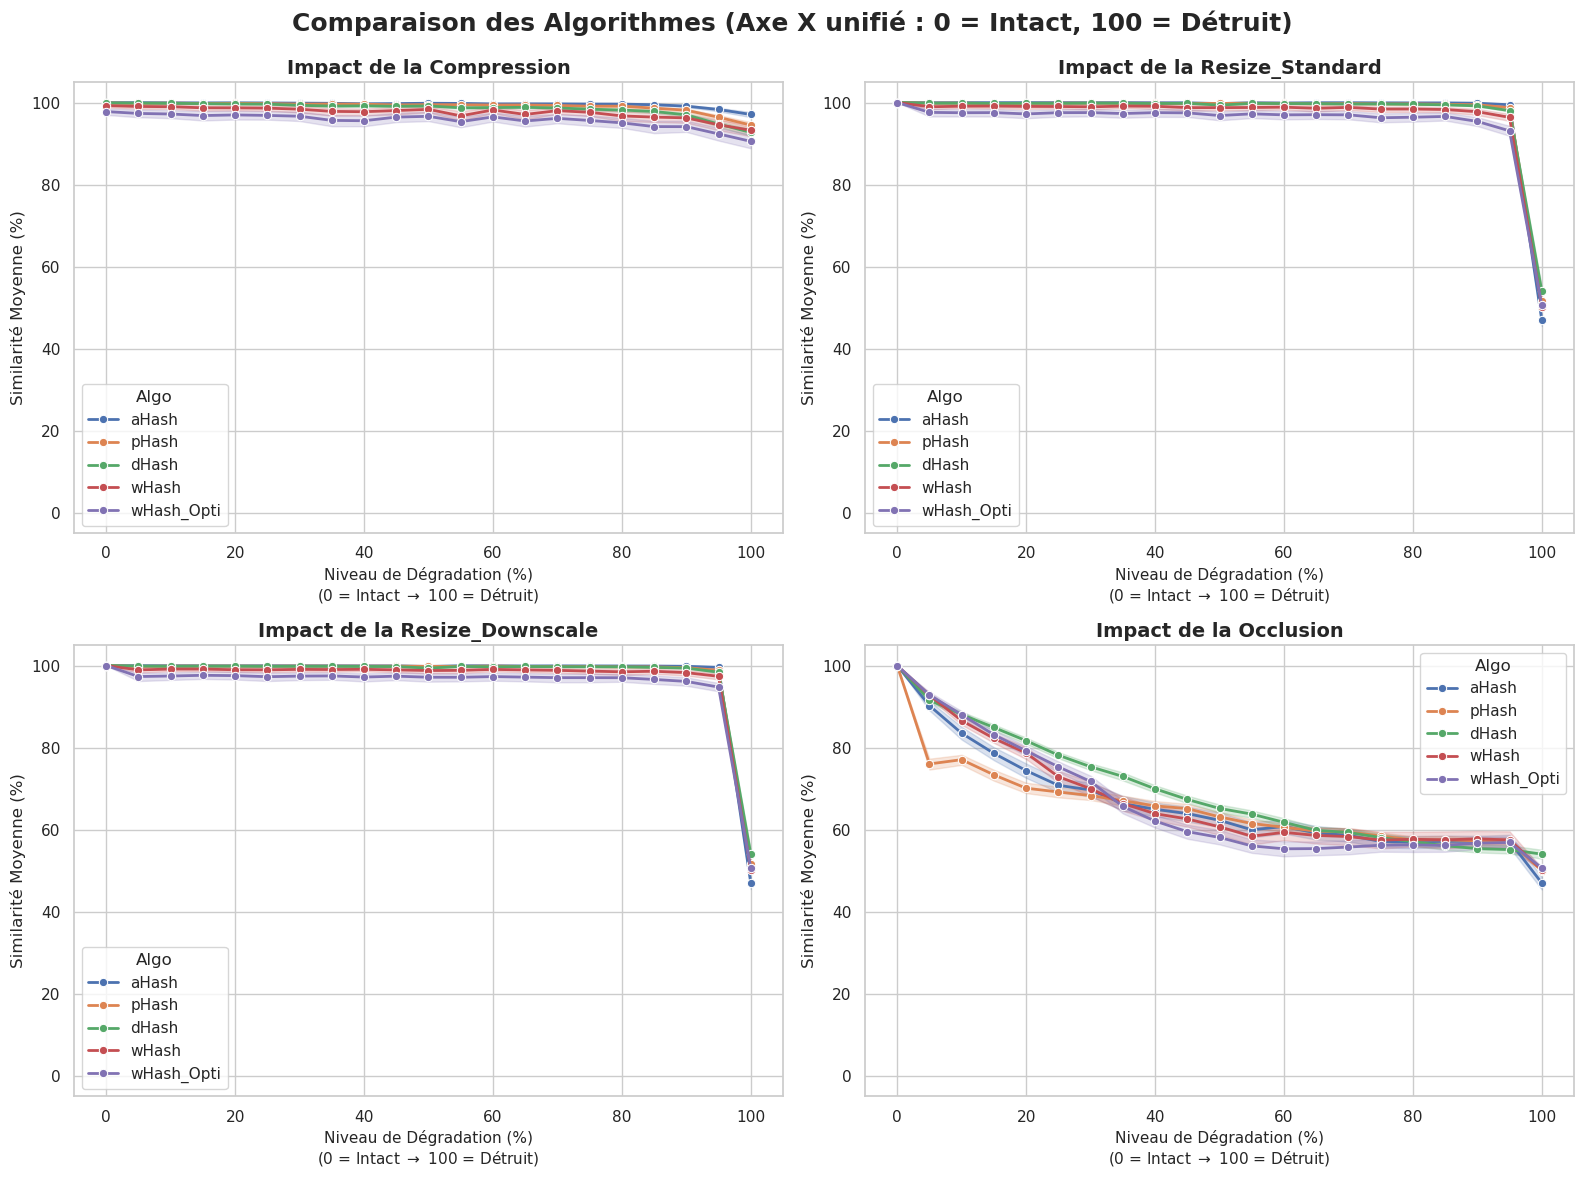

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

#print("Génération des courbes de comparaison des algorithmes...")


def calculer_degradation(row):
    if row['Transformation'] == 'Occlusion':
        return row['Intensite'] # 0% masqué = intact, 100% masqué = détruit
    else:
        return 100 - row['Intensite'] # 100% qualité = 0% dégradation

df_global['Niveau_Degradation'] = df_global.apply(calculer_degradation, axis=1)

# 2. Création de la figure
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 12))
fig1.suptitle("Comparaison des Algorithmes (Axe X unifié : 0 = Intact, 100 = Détruit)", fontsize=18, fontweight='bold')
axes1 = axes1.flatten()

transformations = ['Compression', 'Resize_Standard', 'Resize_Downscale', 'Occlusion']

for i, transfo in enumerate(transformations):
    df_t = df_global[df_global['Transformation'] == transfo]
    
    # On utilise maintenant x='Niveau_Degradation'
    sns.lineplot(data=df_t, x='Niveau_Degradation', y='Similarite_Pct', hue='Algo', marker='o', linewidth=2, ax=axes1[i])
    
    axes1[i].set_title(f"Impact de la {transfo}", fontsize=14, fontweight='bold')
    axes1[i].set_ylabel("Similarité Moyenne (%)", fontsize=12)
    axes1[i].set_ylim(-5, 105)
    
    # Un seul label clair pour tous les graphiques
    axes1[i].set_xlabel("Niveau de Dégradation (%)\n(0 = Intact $\\rightarrow$ 100 = Détruit)", fontsize=11)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

## **5.3 : Comparaison des Catégories d'Images**
Ce bloc génère une figure comparant la vulnérabilité des différents types d'images (visages, logos, paysages, voitures, animaux) face aux mêmes attaques. L'objectif est d'observer si la structure géométrique ou la texture d'une image influence la résistance de son empreinte de hachage.

Génération des courbes de comparaison des catégories d'images...


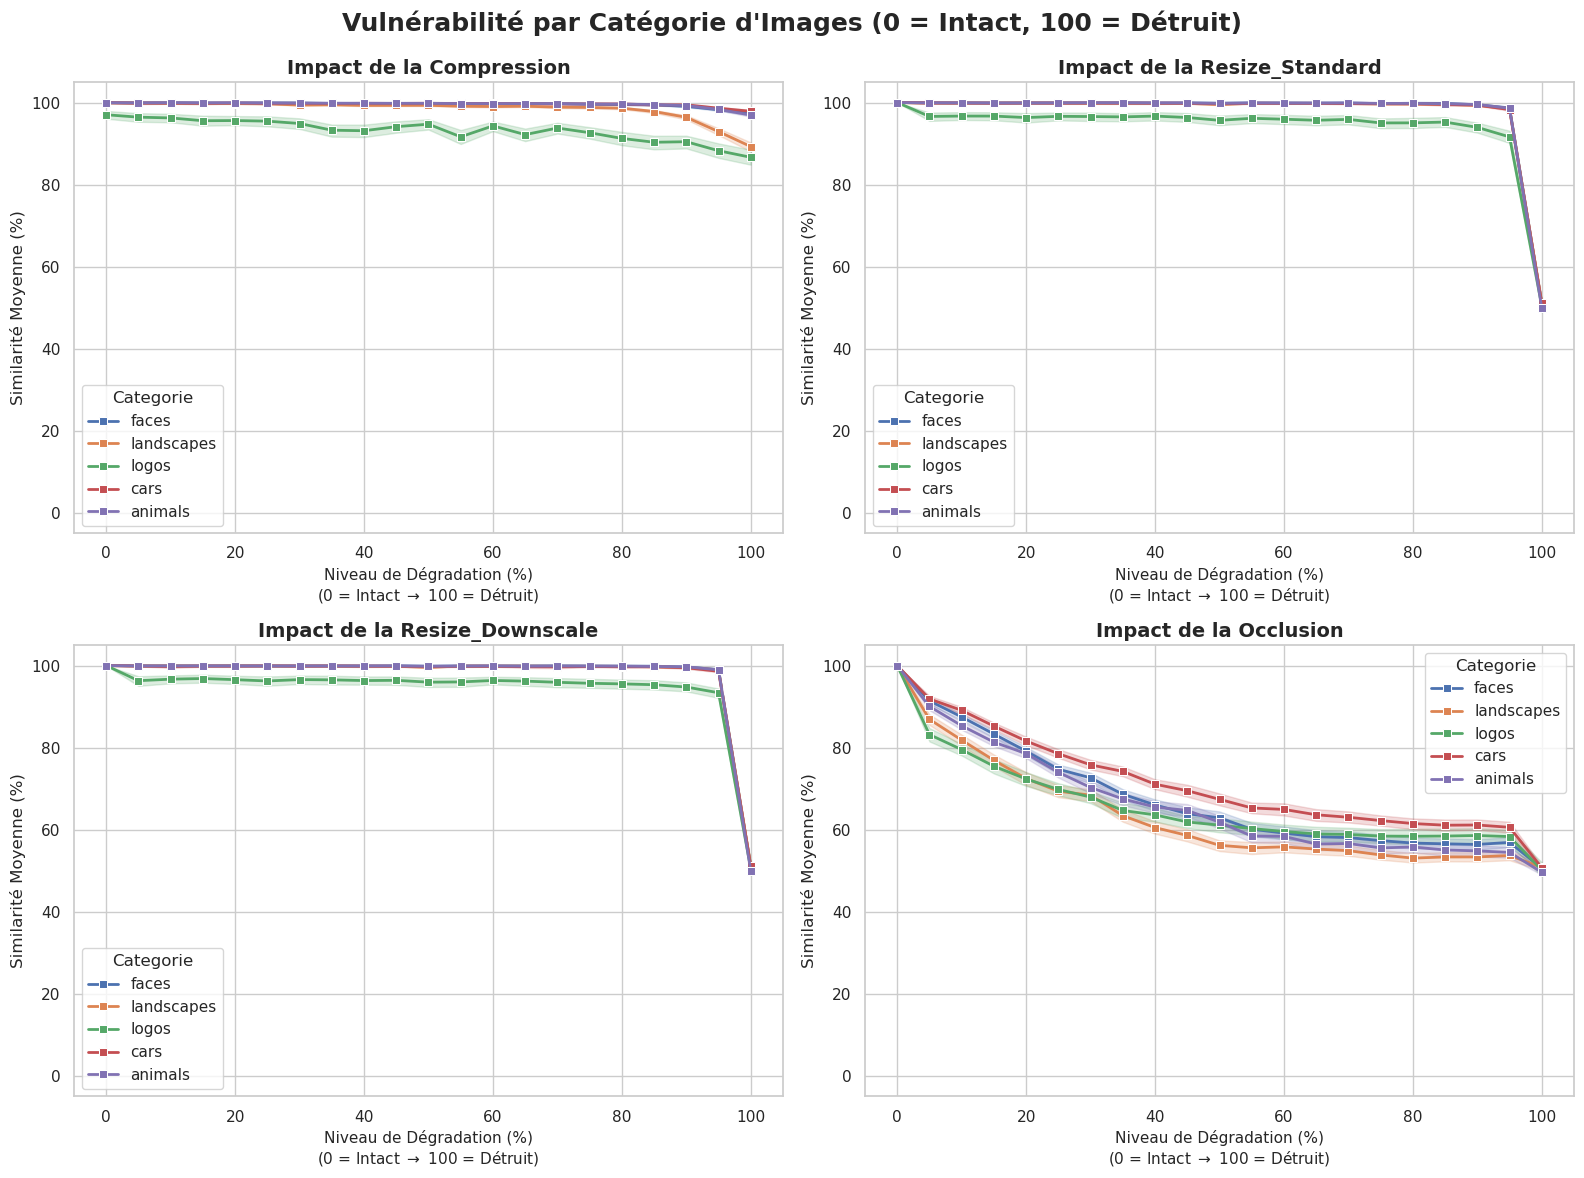

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Génération des courbes de comparaison des catégories d'images...")

# Création de la figure
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle("Vulnérabilité par Catégorie d'Images (0 = Intact, 100 = Détruit)", fontsize=18, fontweight='bold')
axes2 = axes2.flatten()

transformations = ['Compression', 'Resize_Standard', 'Resize_Downscale', 'Occlusion']

for i, transfo in enumerate(transformations):
    df_t = df_global[df_global['Transformation'] == transfo]
    
    sns.lineplot(data=df_t, x='Niveau_Degradation', y='Similarite_Pct', hue='Categorie', marker='s', linewidth=2, ax=axes2[i])
    
    axes2[i].set_title(f"Impact de la {transfo}", fontsize=14, fontweight='bold')
    axes2[i].set_ylabel("Similarité Moyenne (%)", fontsize=12)
    axes2[i].set_ylim(-5, 105)
    
    axes2[i].set_xlabel("Niveau de Dégradation (%)\n(0 = Intact $\\rightarrow$ 100 = Détruit)", fontsize=11)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()